In [2]:
# **Python**

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

import pickle

In [4]:
# Load the data

with open('preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
scaler = data['scaler']

# Re-create scaled versions using the already-fitted scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data loaded and scaled!")

Data loaded and scaled!


### Train the model with Random Forest

In [5]:
#  ---------------------------------------------------------- Random Forest ---------------------------------------------------------------------------------------

# n_estimators: number of trees in the forest
# max_features='sqrt': each split considers only √d random features (as in the slide)
# class_weight='balanced': same logic as Logistic Regression, compensates for 75/25 imbalance
rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

print("Random Forest trained!")

Random Forest trained!


In [6]:
# Predict on test set
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

# ROC-AUC
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"ROC-AUC: {auc_rf:.3f}")
print()

# Precision, Recall, F1
print(classification_report(y_test, y_pred_rf, target_names=['Non-MT', 'MT']))
print()

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

ROC-AUC: 0.881

              precision    recall  f1-score   support

      Non-MT       0.87      0.89      0.88       150
          MT       0.64      0.60      0.62        50

    accuracy                           0.81       200
   macro avg       0.75      0.74      0.75       200
weighted avg       0.81      0.81      0.81       200


Confusion Matrix:
[[133  17]
 [ 20  30]]


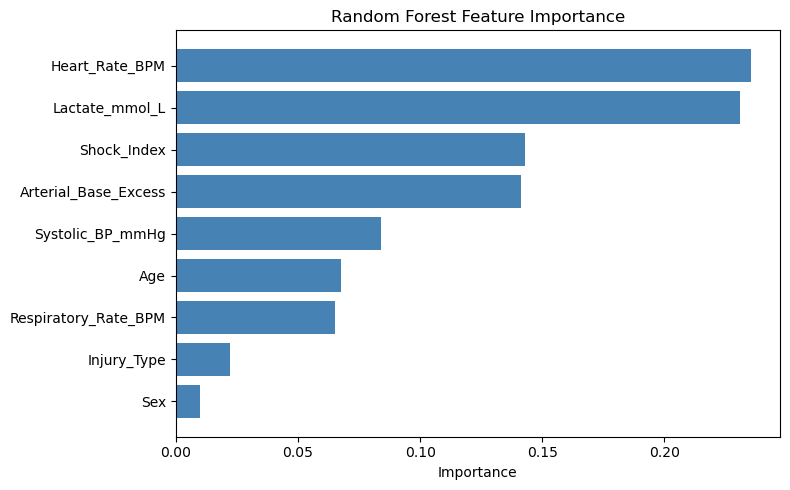

In [7]:
# Feature Importance

importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf.feature_importances_}).sort_values('Importance',ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



### Hyperparameter Tuning — min_samples_leaf


In [8]:
# Try different min_samples_leaf values
for leaf_size in [1, 5, 10, 20, 30, 50, 100]:
    rf_test = RandomForestClassifier(
        n_estimators=100,
        max_features='sqrt',
        min_samples_leaf=leaf_size,
        class_weight='balanced',
        random_state=42
    )
    rf_test.fit(X_train, y_train)
    
    y_pred = rf_test.predict(X_test)
    y_pred_proba = rf_test.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_pred_proba)
    recall_mt = classification_report(y_test, y_pred, target_names=['Non-MT','MT'], output_dict=True)['MT']['recall']
    
    print(f"min_samples_leaf={leaf_size}: ROC-AUC={auc:.3f}, Recall(MT)={recall_mt:.3f}")

min_samples_leaf=1: ROC-AUC=0.881, Recall(MT)=0.600
min_samples_leaf=5: ROC-AUC=0.885, Recall(MT)=0.740
min_samples_leaf=10: ROC-AUC=0.881, Recall(MT)=0.740
min_samples_leaf=20: ROC-AUC=0.884, Recall(MT)=0.740
min_samples_leaf=30: ROC-AUC=0.883, Recall(MT)=0.760
min_samples_leaf=50: ROC-AUC=0.881, Recall(MT)=0.780
min_samples_leaf=100: ROC-AUC=0.882, Recall(MT)=0.780


### The results increased. 
Let's try to improve the estimator.

In [9]:
results = []

for leaf_size in [5,10,15,20, 30, 50, 100]:
    for n_trees in [100, 200, 300, 500]:
        rf_test = RandomForestClassifier(
            n_estimators=n_trees,
            max_features='sqrt',
            min_samples_leaf=leaf_size,
            class_weight='balanced',
            random_state=42
        )
        rf_test.fit(X_train, y_train)
        
        y_pred = rf_test.predict(X_test)
        y_pred_proba = rf_test.predict_proba(X_test)[:, 1]
        
        auc = roc_auc_score(y_test, y_pred_proba)
        recall_mt = classification_report(y_test, y_pred, target_names=['Non-MT','MT'], output_dict=True)['MT']['recall']
        
        results.append({
            'min_samples_leaf': leaf_size,
            'n_estimators': n_trees,
            'ROC_AUC': round(auc, 3),
            'Recall_MT': round(recall_mt, 3),
            'Precision_MT': round(classification_report(y_test, y_pred, target_names=['Non-MT','MT'], output_dict=True)['MT']['precision'], 3)
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 min_samples_leaf  n_estimators  ROC_AUC  Recall_MT  Precision_MT
                5           100    0.885       0.74         0.597
                5           200    0.882       0.74         0.597
                5           300    0.881       0.74         0.607
                5           500    0.883       0.74         0.617
               10           100    0.881       0.74         0.561
               10           200    0.881       0.74         0.587
               10           300    0.882       0.76         0.594
               10           500    0.883       0.76         0.594
               15           100    0.883       0.74         0.569
               15           200    0.883       0.74         0.569
               15           300    0.882       0.76         0.576
               15           500    0.882       0.76         0.576
               20           100    0.884       0.74         0.552
               20           200    0.884       0.76         0.576
          

In [10]:
# Final Model Random Forest

rf_final = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',
    min_samples_leaf=30,
    class_weight='balanced',
    random_state=42
)

rf_final.fit(X_train, y_train)

y_pred_final = rf_final.predict(X_test)
y_pred_proba_final = rf_final.predict_proba(X_test)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_final):.3f}")
print()
print(classification_report(y_test, y_pred_final, target_names=['Non-MT', 'MT']))
print()
print(confusion_matrix(y_test, y_pred_final))

ROC-AUC: 0.883

              precision    recall  f1-score   support

      Non-MT       0.92      0.76      0.83       150
          MT       0.53      0.80      0.63        50

    accuracy                           0.77       200
   macro avg       0.72      0.78      0.73       200
weighted avg       0.82      0.77      0.78       200


[[114  36]
 [ 10  40]]


In [11]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_check = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',
    min_samples_leaf=30,
    class_weight='balanced',
    random_state=42
)

# Check ROC-AUC on train (overfitting check)
auc_train = cross_val_score(rf_check, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"CV ROC-AUC (train): {auc_train.mean():.3f} ± {auc_train.std():.3f}")

# Check Recall on train
recall_train = cross_val_score(rf_check, X_train, y_train, cv=cv, scoring='recall')
print(f"CV Recall MT (train): {recall_train.mean():.3f} ± {recall_train.std():.3f}")

precision_train = cross_val_score(rf_check, X_train, y_train, cv=cv, scoring='precision')
print(f"CV Precision MT: {precision_train.mean():.3f} ± {precision_train.std():.3f}")

CV ROC-AUC (train): 0.895 ± 0.024
CV Recall MT (train): 0.820 ± 0.070
CV Precision MT: 0.547 ± 0.042


### Optimal threshold

In [12]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_final)
youden = tpr - fpr
optimal_threshold = thresholds[youden.argmax()]
print(f"Optimal threshold: {optimal_threshold:.3f}")

Optimal threshold: 0.578


In [13]:
# Apply optimal threshold to final RF model
y_pred_optimal_rf = (y_pred_proba_final >= optimal_threshold).astype(int)

print(f"=== Random Forest — Optimal Threshold ({optimal_threshold:.3f}) ===")
print(classification_report(y_test, y_pred_optimal_rf, target_names=['Non-MT', 'MT']))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimal_rf))

=== Random Forest — Optimal Threshold (0.578) ===
              precision    recall  f1-score   support

      Non-MT       0.90      0.87      0.89       150
          MT       0.65      0.72      0.69        50

    accuracy                           0.83       200
   macro avg       0.78      0.80      0.79       200
weighted avg       0.84      0.83      0.84       200


Confusion Matrix:
[[131  19]
 [ 14  36]]


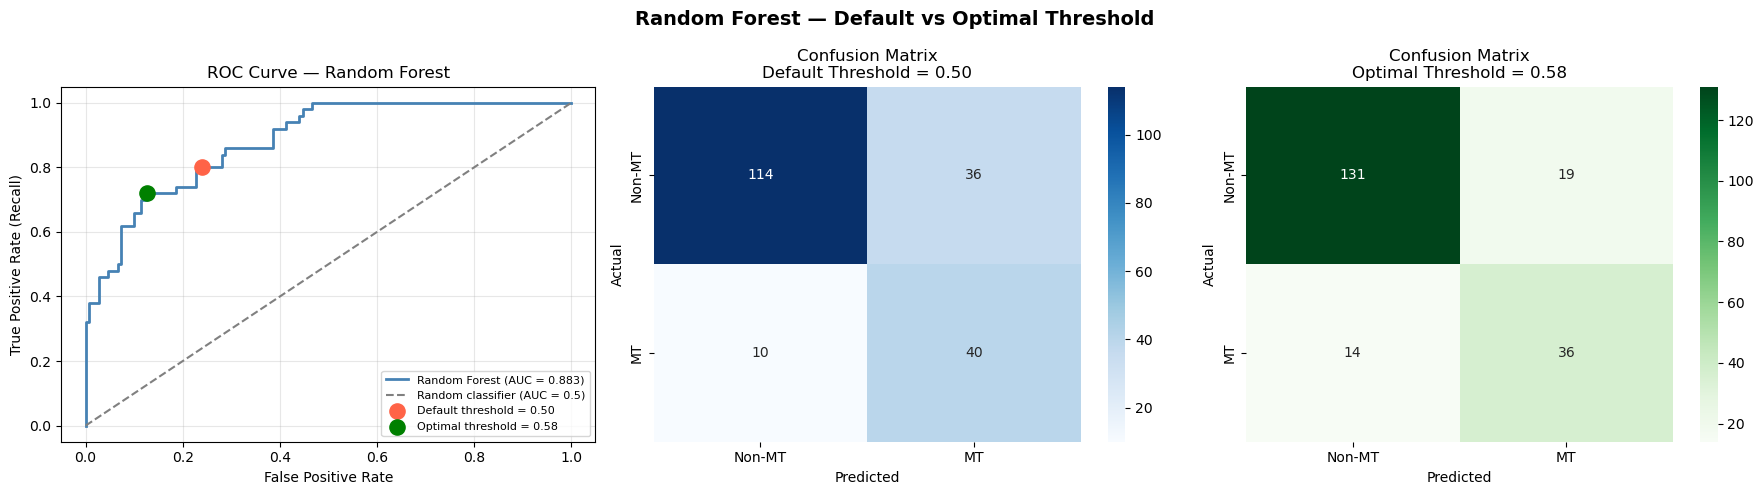

In [15]:
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. ROC Curve with both thresholds marked ──
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_final)
auc = roc_auc_score(y_test, y_pred_proba_final)

axes[0].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'Random Forest (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--',
             label='Random classifier (AUC = 0.5)')

# Default threshold point
y_pred_default = (y_pred_proba_final >= 0.5).astype(int)
fpr_default = (y_pred_default[y_test == 0] == 1).sum() / (y_test == 0).sum()
tpr_default = (y_pred_default[y_test == 1] == 1).sum() / (y_test == 1).sum()
axes[0].scatter(fpr_default, tpr_default, color='tomato', s=120, zorder=5,
                label='Default threshold = 0.50')

# Optimal threshold point
optimal_idx = (tpr - fpr).argmax()
axes[0].scatter(fpr[optimal_idx], tpr[optimal_idx], color='green', s=120, zorder=5,
                label=f'Optimal threshold = {optimal_threshold:.2f}')

axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve — Random Forest')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# ── 2. Confusion Matrix — Default threshold ──
cm_default = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-MT', 'MT'],
            yticklabels=['Non-MT', 'MT'], ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix\nDefault Threshold = 0.50')

# ── 3. Confusion Matrix — Optimal threshold ──
cm_optimal = confusion_matrix(y_test, y_pred_optimal_rf)
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-MT', 'MT'],
            yticklabels=['Non-MT', 'MT'], ax=axes[2])
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_title(f'Confusion Matrix\nOptimal Threshold = {optimal_threshold:.2f}')

plt.suptitle('Random Forest — Default vs Optimal Threshold',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ABC Score 

In [70]:
# Compute simplified ABC Score on TEST set only
ABC_pred = (
    (X_test['Injury_Type'] == 1).astype(int) +
    (X_test['Systolic_BP_mmHg'] <= 90).astype(int) +
    (X_test['Heart_Rate_BPM'] >= 120).astype(int)
)

# ABC predicts MT if score >= 2
ABC_pred_binary = (ABC_pred >= 2).astype(int)

print("=== Simplified ABC Score (without FAST) ===")
print(f"ROC-AUC: {roc_auc_score(y_test, ABC_pred):.3f}")
print()
print(classification_report(y_test, ABC_pred_binary, target_names=['Non-MT', 'MT']))

=== Simplified ABC Score (without FAST) ===
ROC-AUC: 0.747

              precision    recall  f1-score   support

      Non-MT       0.83      0.99      0.90       150
          MT       0.90      0.38      0.54        50

    accuracy                           0.83       200
   macro avg       0.87      0.68      0.72       200
weighted avg       0.85      0.83      0.81       200

